In [53]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from sklearn.datasets import make_spd_matrix

from mis_dro.bayes_conjugates import *
from mis_dro.dataset import sample_dgp

In [54]:
replication = 3
generator = np.random.default_rng(replication)
dim = 5
num_observations = 20

# plot and sample from the DGP
xi = sample_dgp("multivariate_normal", num_observations, dim=dim)
xi_sum = np.sum(xi, axis=0)
xi_mean = np.mean(xi, axis=0)

prior_params = default_prior_params("normal_inverse_wishart", dim=dim)
mu_prior, kappa_prior, iota_prior, Psi_prior = prior_params
# mu_prior = np.array([10.0, 20.0, 30.0, 35.0, 22.0])
mu_prior = xi.mean(axis=0)
# NOTE below sets the prior mean to be the same as the DGP (tests for prior misspecification)
prior_params = (mu_prior, kappa_prior, iota_prior, Psi_prior)

### Sample from the prior - visualise first two dimensions

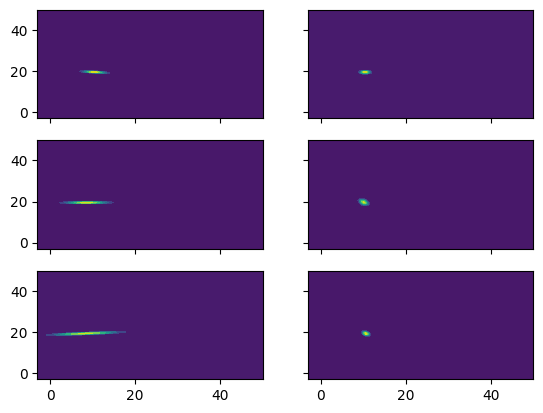

In [55]:
max_samples = 6
prior_samples = normal_inverse_wishart_samples(max_samples, mu_prior, kappa_prior, iota_prior, Psi_prior, generator=generator)

axis1, axis2 = np.mgrid[-3:50:0.1, -3:50:0.1]
fig, axes = plt.subplots(nrows=int(np.ceil(max_samples/2)), ncols=2, sharex=True, sharey=True)
for i, vec in enumerate(prior_samples):
    mu = vec[:dim]
    cov = reconstruct_covariance_from_triu(vec[dim:], dim)
    if i >= max_samples:
        break
    axes[int(i/ 2)][i%2].contourf(axis1, axis2, sp.stats.multivariate_normal(mu[:2], cov[:2,:2], seed=generator).pdf(np.dstack((axis1, axis2))))



In [56]:
sklearn_cov_seed = 1
sklearn_random_state = np.random.RandomState(seed=sklearn_cov_seed)
cov_multiplier = 20.0
dgp_mean = [10.0, 20.0, 30.0, 35.0, 22.0]
dgp_cov = cov_multiplier * make_spd_matrix(dim, random_state=sklearn_random_state)


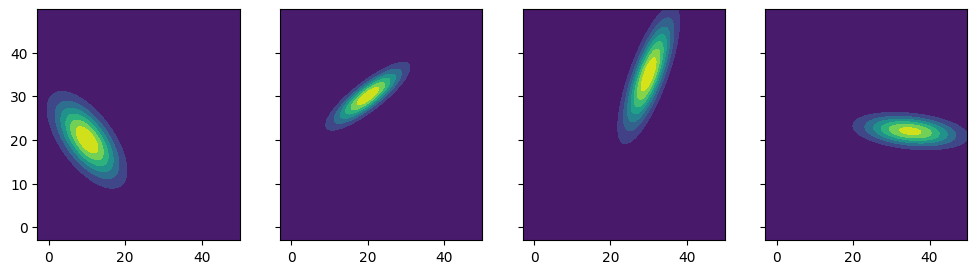

In [57]:
# visualise slices of the DGP
fig, axes = plt.subplots(ncols=dim-1, nrows=1, sharex=True, sharey=True, figsize=(12,3))
for d in range(dim-1):
    dgp_dist = sp.stats.multivariate_normal(dgp_mean[d:d+2], dgp_cov[d:d+2,d:d+2])
    axes[d].contourf(axis1, axis2, dgp_dist.pdf(np.dstack((axis1,axis2))))
fig.show()

In [58]:
post_params = get_posterior_params("normal_inverse_wishart", xi, prior_params)
mu_post, kappa_post, iota_post, Psi_post = post_params

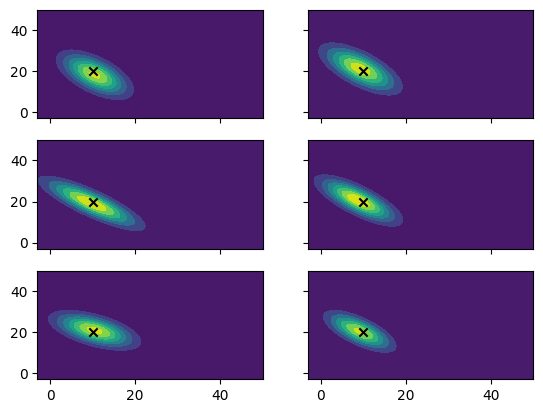

In [59]:
post_samples = normal_inverse_wishart_samples(max_samples, *post_params, generator=generator)
axis1, axis2 = np.mgrid[-3:50:0.1, -3:50:0.1]
fig, axes = plt.subplots(nrows=int(np.ceil(max_samples/2)), ncols=2, sharex=True, sharey=True)
for i, vec in enumerate(post_samples):
    mu = vec[:dim]
    cov = reconstruct_covariance_from_triu(vec[dim:], dim)
    if i >= max_samples:
        break
    axes[int(i/ 2)][i%2].contourf(axis1, axis2, sp.stats.multivariate_normal(mu[:2], cov[:2,:2], seed=generator).pdf(np.dstack((axis1, axis2))))
    axes[int(i/ 2)][i%2].scatter(dgp_mean[0], dgp_mean[1], marker="x", color="black")

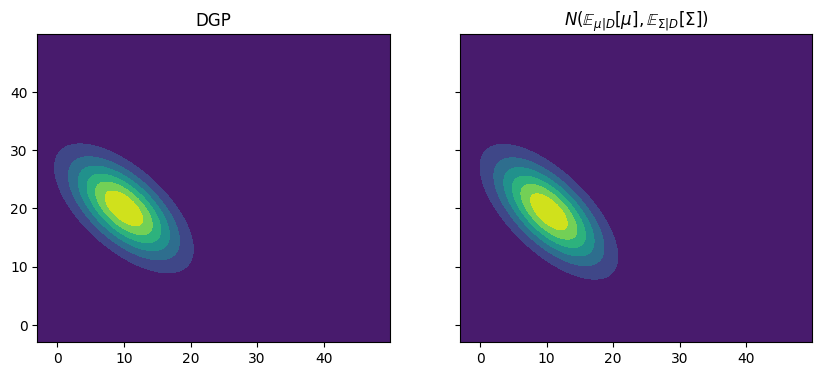

In [60]:
# plot expected Sigma next to DGP
fig, (ax1, ax2) = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(10,4))
expected_Sigma = Psi_post / (iota_post - Psi_post.shape[0] - 1)
dgp_dist = sp.stats.multivariate_normal(dgp_mean[:2], dgp_cov[:2,:2], seed=generator)
ax1.contourf(axis1, axis2, dgp_dist.pdf(np.dstack((axis1,axis2))))
ax1.set_title("DGP")
# ax2.contourf(axis1, axis2, sp.stats.multivariate_normal(post_mu_samples[0], post_cov_samples[0], seed=generator).pdf(np.dstack((axis1,axis2))))
ax2.contourf(axis1, axis2, sp.stats.multivariate_normal(mu_post[:2], expected_Sigma[:2,:2], seed=generator).pdf(np.dstack((axis1,axis2))))
ax2.set_title(r"$N(\mathbb{E}_{\mu | D}[\mu], \mathbb{E}_{\Sigma | D}[\Sigma])$")
fig.show()

### Plot $\mathcal{N}(\hat{\mu}, \hat{\Sigma})$ where $ \hat{\Sigma} = \frac{1}{2} \left(\overset{\frown}{\mu} \overset{\frown}{\mu}^\top - \overset{\frown}{\kappa}^{-1} \overset{\frown}{\Psi} \right)^{-1}$ and $\hat{\mu} = \hat{\Sigma} \overset{\frown}{\mu}$.


**Problem:** The matrix $\hat{\Sigma}$ is not PSD! The diagonals are negative!

In [61]:
Sigma_hat = (1/(kappa_post - dim - 2))*Psi_post
mu_hat = mu_post
Sigma_hat

array([[ 21.27865731, -15.85603401, -15.24708623, -29.51164331,
          6.62281732],
       [-15.85603401,  26.70910059,  18.65436336,  36.80097525,
         -2.65560142],
       [-15.24708623,  18.65436336,  16.99140111,  31.21903732,
         -3.63943446],
       [-29.51164331,  36.80097525,  31.21903732,  75.78540057,
         -9.30545789],
       [  6.62281732,  -2.65560142,  -3.63943446,  -9.30545789,
          3.48648508]])

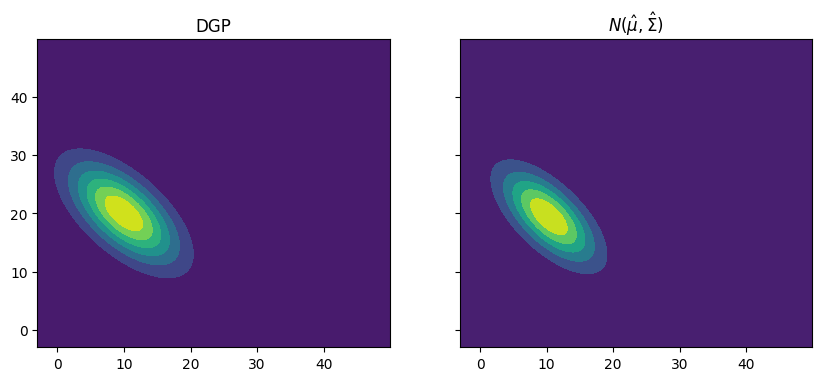

In [62]:
# plot hat{Sigma} next to the DGP
fig, (ax1, ax2) = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(10,4))



# mu_hat, Sigma_hat = derive_analytical_posterior_params("normal_inverse_wishart", post_params)

dgp_dist = sp.stats.multivariate_normal(dgp_mean[:2], dgp_cov[:2,:2], seed=generator)
ax1.contourf(axis1, axis2, dgp_dist.pdf(np.dstack((axis1,axis2))))
ax1.set_title("DGP")
# ax2.contourf(axis1, axis2, sp.stats.multivariate_normal(post_mu_samples[0], post_cov_samples[0], seed=generator).pdf(np.dstack((axis1,axis2))))
ax2.contourf(axis1, axis2, sp.stats.multivariate_normal(mu_hat[:2], Sigma_hat[:2,:2], seed=generator).pdf(np.dstack((axis1,axis2))))
ax2.set_title(r"$N(\hat{\mu}, \hat{\Sigma})$")
fig.show()

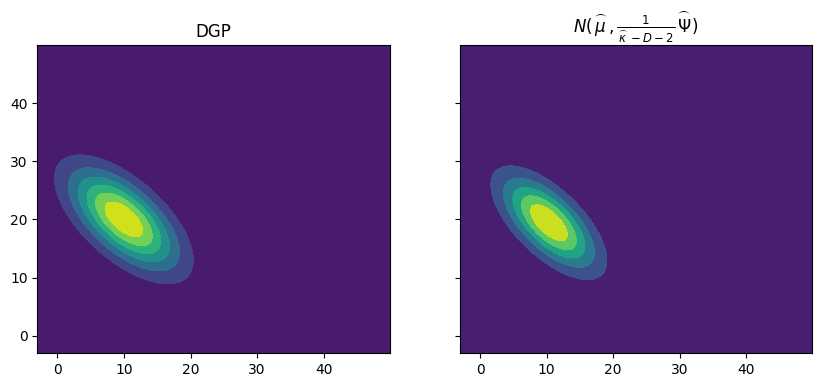

In [63]:
fig, (ax1, ax2) = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(10,4))

Sigma_hat = (1/(kappa_post - dim - 2))*Psi_post
# Sigma_hat = (1/(iota_post))*Psi_post

mu_hat =  mu_post

dgp_dist = sp.stats.multivariate_normal(dgp_mean[:2], dgp_cov[:2,:2], seed=generator)
ax1.contourf(axis1, axis2, dgp_dist.pdf(np.dstack((axis1,axis2))))
ax1.set_title("DGP")
# ax2.contourf(axis1, axis2, sp.stats.multivariate_normal(post_mu_samples[0], post_cov_samples[0], seed=generator).pdf(np.dstack((axis1,axis2))))
ax2.contourf(axis1, axis2, sp.stats.multivariate_normal(mu_hat[:2], Sigma_hat[:2,:2], seed=generator).pdf(np.dstack((axis1,axis2))))
ax2.set_title(r"$N(\overset{\frown}{\mu}, \frac{1}{\overset{\frown}{\kappa} - D - 2} \overset{\frown}{\Psi})$")
fig.show()

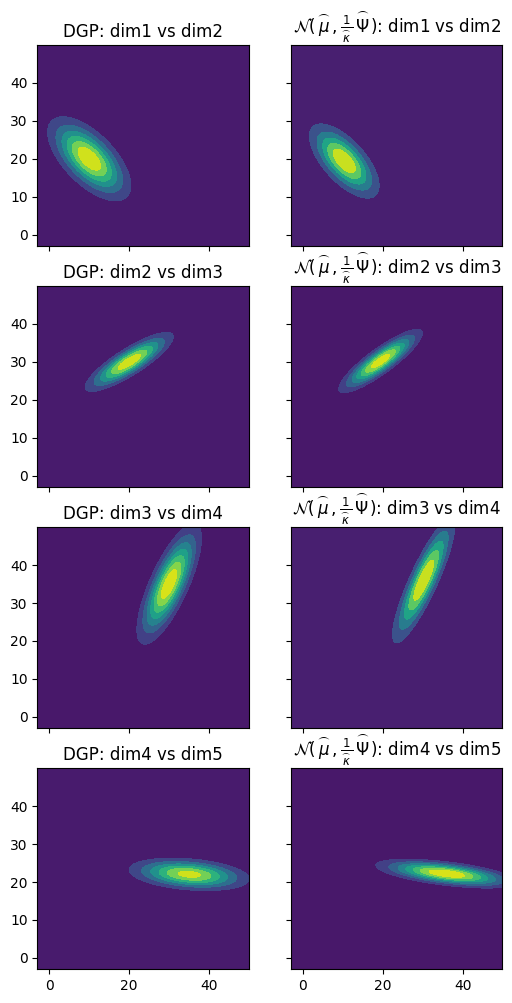

In [64]:
# visualise slices of the DGP
fig, axes = plt.subplots(ncols=2, nrows=dim-1, sharex=True, sharey=True, figsize=(6,12))
for d in range(dim-1):
    dgp_dist = sp.stats.multivariate_normal(dgp_mean[d:d+2], dgp_cov[d:d+2,d:d+2])
    axes[d][0].contourf(axis1, axis2, dgp_dist.pdf(np.dstack((axis1,axis2))))
    axes[d][0].set_title(f"DGP: dim{d+1} vs dim{d+2}")
    sad_dist = sp.stats.multivariate_normal(mu_hat[d:d+2], Sigma_hat[d:d+2,d:d+2], seed=generator)
    axes[d][1].contourf(axis1, axis2, sad_dist.pdf(np.dstack((axis1,axis2))))
    axes[d][1].set_title(r"$\mathcal{N}(\overset{\frown}{\mu}, \frac{1}{\overset{\frown}{\kappa}} \overset{\frown}{\Psi})$: " + f"dim{d+1} vs dim{d+2}")
fig.show()